# Late Delivery Prediction — E-Commerce

> **Goal:** Predict whether an order will be delivered **late** or **on time** *before shipment* so that high-risk orders can be prioritised operationally.

| | |
|---|---|
| **Dataset** | E-commerce shipment records (10,999 rows × 12 features) |
| **Target** | `Reached.on.Time_Y.N` — `1` = Late, `0` = On-Time |
| **Algorithm** | Logistic Regression with class-weight tuning |
| **Key metric** | Recall for Late class (minimise missed late deliveries) |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Overview

The dataset contains order-level features such as warehouse block, shipment mode, customer care calls, discount offered, and product weight.

In [2]:
df = pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Shape:", df.shape)

Shape: (10999, 12)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [5]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

> **Note:** In this dataset `Reached.on.Time_Y.N = 1` means the product did **NOT** reach on time (Late), and `0` means it reached on time (On-Time). Approximately 60 % of orders are late, making this a moderately imbalanced classification problem.

In [6]:
target_counts = df['Reached.on.Time_Y.N'].value_counts()
print(target_counts)
print(f"\nLate (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")
print(f"On-Time (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Late (1): 6563 (59.7%)
On-Time (0): 4436 (40.3%)


### 3.2 Shipment Mode Distribution

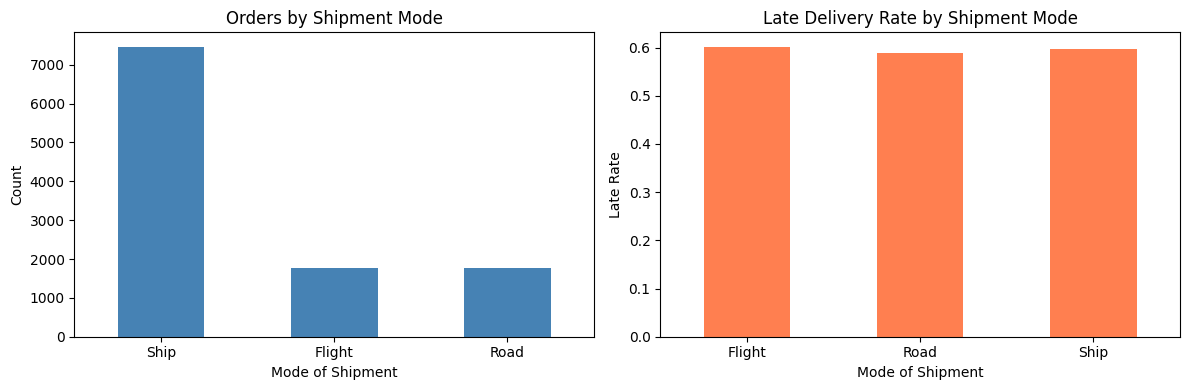

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Shipment mode counts
df['Mode_of_Shipment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Orders by Shipment Mode')
axes[0].set_xlabel('Mode of Shipment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Late delivery rate by shipment mode
late_rate = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean()
late_rate.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Late Delivery Rate by Shipment Mode')
axes[1].set_xlabel('Mode of Shipment')
axes[1].set_ylabel('Late Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.3 Missing Values Check

In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per column:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Total missing: 0


## 4. Feature Engineering

Steps:
1. Drop the `ID` column — it is a row identifier with no predictive value.
2. Identify categorical columns.
3. Apply one-hot encoding (drop first level to avoid multicollinearity).

In [9]:
df = df.drop(columns=['ID'])

In [10]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [11]:
df = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (10999, 16)


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,4,2,177,3,44,1233,1,False,False,True,False,False,False,True,False,False
1,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,False,True
2,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,False,True
3,3,3,176,4,10,1177,1,True,False,False,False,False,False,False,True,True
4,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,True,False


## 5. Train / Test Split

An 80 / 20 split with `random_state=42` is used for reproducibility.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (8799, 15)
Test set:     (2200, 15)


## 6. Baseline Logistic Regression

A vanilla Logistic Regression model without any class-weight adjustment is trained first to establish a performance baseline.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_baseline = LogisticRegression(max_iter=1000, random_state=42)
model_baseline.fit(X_train, y_train)

y_pred_baseline = model_baseline.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=['On-Time (0)', 'Late (1)']))

Baseline Accuracy: 0.6473

              precision    recall  f1-score   support

 On-Time (0)       0.57      0.57      0.57       895
    Late (1)       0.70      0.70      0.70      1305

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.65      0.65      2200



## 7. Business-Tuned Model — Class-Weight Optimization

**Business rationale:** Missing a late delivery (False Negative for class `1`) is more costly than a false alarm. We therefore increase the penalty for misclassifying Late orders by setting `class_weight={0: 1, 1: 2}`, which boosts the **recall for the Late class** at a small cost to precision.

> `Reached.on.Time_Y.N = 1` → **Late** → class we want high recall on  
> `Reached.on.Time_Y.N = 0` → **On-Time**

In [14]:
model_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight={0: 1, 1: 2}  # higher weight for Late class to boost its recall
)

model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
print(classification_report(y_test, y_pred_weighted, target_names=['On-Time (0)', 'Late (1)']))

              precision    recall  f1-score   support

 On-Time (0)       0.64      0.08      0.15       895
    Late (1)       0.61      0.97      0.75      1305

    accuracy                           0.61      2200
   macro avg       0.62      0.53      0.45      2200
weighted avg       0.62      0.61      0.50      2200



### Key Takeaway

By up-weighting the Late class the model achieves **higher recall on Late deliveries** compared to the baseline, meaning fewer late orders are missed before shipment. We intentionally accept a slight drop in On-Time recall because the business cost of missing a late delivery is greater than a false alarm.

## 8. Save Model

The tuned model is serialised with `joblib` for use in the batch prediction pipeline (`predict.py`).

In [15]:
import joblib

joblib.dump(model_weighted, 'late_delivery_model.pkl')
print('Model saved as late_delivery_model.pkl')

Model saved as late_delivery_model.pkl


## 9. Deployment Strategy

The model is deployed as a **batch prediction pipeline**:

1. Daily orders are exported to `new_orders.csv`.
2. `predict.py` loads the saved model and scores all orders.
3. Orders predicted as **Late** are flagged for **Priority Shipment**.
4. Results are written to `prediction_results.csv` for the operations team.

```
python predict.py
```